# ECO462: Homework 6

                Item       Value
0                 B1   89.703835
1                 B2   80.944627
2    Portfolio Value  170.648463
3                 D1    4.762550
4                 D2    5.956011
5                 C1   26.112334
6                 C2   42.543790
7           Z2_price   85.898828
8           Z8_price   42.827062
9   k1_duration_conv   -1.444084
10  k2_duration_conv   -1.929959
11    kS_level_slope   -1.444084
12    kL_level_slope   -1.929959


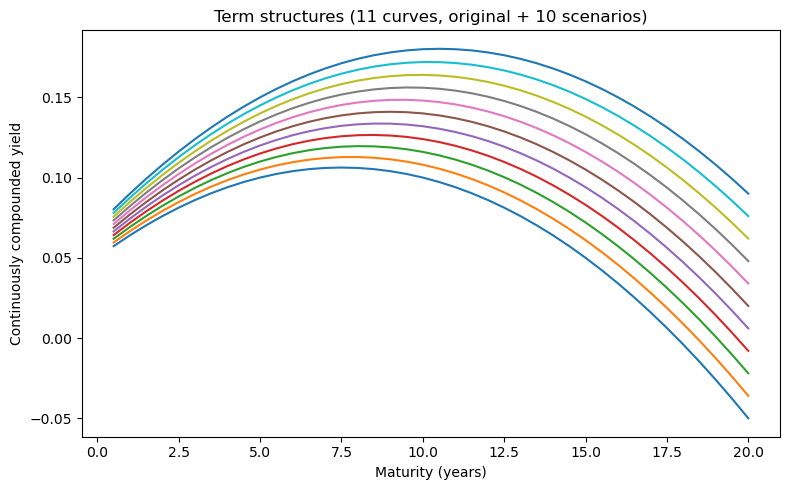

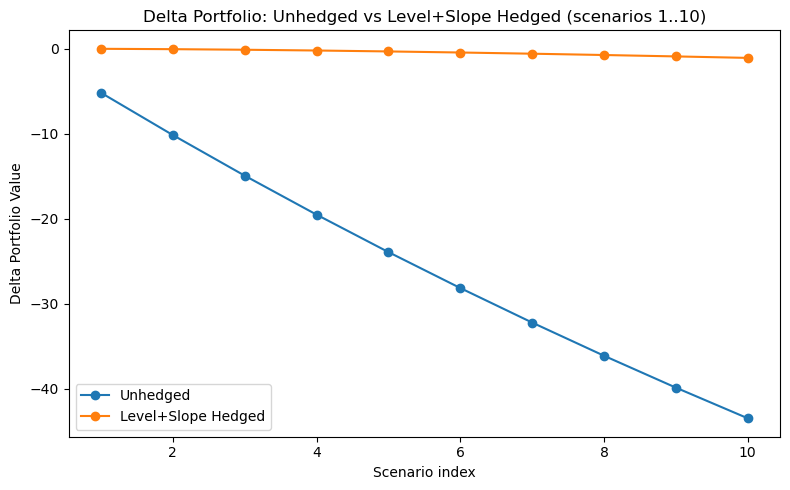

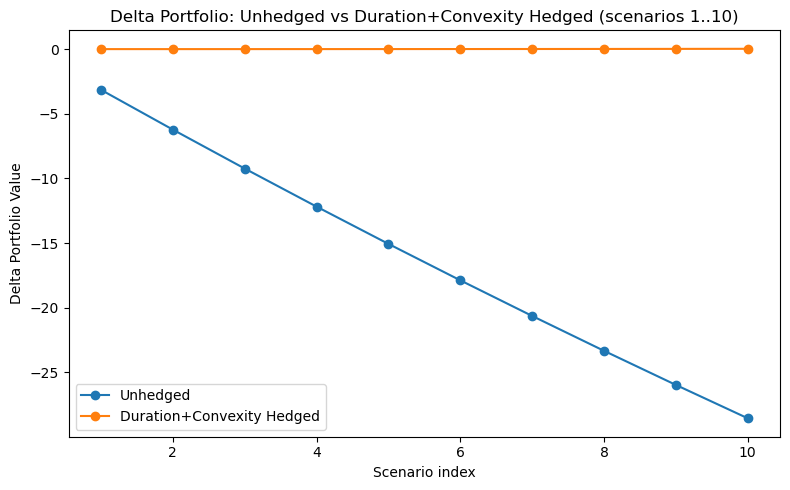

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

beta1 = 0.05
beta2 = 0.015
beta3 = -0.0010
face = 100.0

def R_of_T(T, b1=beta1, b2=beta2, b3=beta3):
    return b1 + b2*T + b3*(T**2)

def bond_cashflows(coupon_per_period, n_periods):
    times = np.arange(1, n_periods+1) * 0.5
    cfs = np.full(n_periods, coupon_per_period)
    cfs[-1] += face
    return times, cfs

def price_from_cfs(times, cfs, b1=beta1, b2=beta2, b3=beta3):
    dfs = np.exp(- (b1 + b2*times + b3*(times**2)) * times)
    return np.sum(cfs * dfs)

def duration_convexity(times, cfs, price, b1=beta1, b2=beta2, b3=beta3):
    dfs = np.exp(- (b1 + b2*times + b3*(times**2)) * times)
    pv = cfs * dfs
    w = pv / price
    duration = np.sum(w * times)
    convexity = np.sum(w * times**2)
    return duration, convexity, w, pv

times1, cfs1 = bond_cashflows(4.0, 12)
times2, cfs2 = bond_cashflows(3.5, 16)

B1 = price_from_cfs(times1, cfs1)
B2 = price_from_cfs(times2, cfs2)
portfolio_value = B1 + B2

D1, C1, w1, pv1 = duration_convexity(times1, cfs1, B1)
D2, C2, w2, pv2 = duration_convexity(times2, cfs2, B2)

Tz1 = 2.0
Tz2 = 8.0
Z2 = 100.0 * np.exp(- (beta1 + beta2*Tz1 + beta3*(Tz1**2)) * Tz1)
Z8 = 100.0 * np.exp(- (beta1 + beta2*Tz2 + beta3*(Tz2**2)) * Tz2)
Dz2 = Tz1; Dz8 = Tz2
Cz2 = Tz1**2; Cz8 = Tz2**2

Bc = portfolio_value
D_port = (B1*D1 + B2*D2) / Bc
C_port = (B1*C1 + B2*C2) / Bc

k1 = -Bc / Z2 * (D_port * Cz8 - C_port * Dz8) / (Dz2 * Cz8 - Cz2 * Dz8)
k2 = -Bc / Z8 * (D_port * Cz2 - C_port * Dz2) / (Dz8 * Cz2 - Cz8 * Dz2)

def factor_durations(times, cfs, price, b1=beta1, b2=beta2, b3=beta3):
    dfs = np.exp(- (b1 + b2*times + b3*(times**2)) * times)
    pv = cfs * dfs
    w = pv / price
    D_level = np.sum(w * times * 1.0)
    D_slope = np.sum(w * times * times)
    return D_level, D_slope

B1_lev, B1_slo = factor_durations(times1, cfs1, B1)
B2_lev, B2_slo = factor_durations(times2, cfs2, B2)

P = Bc
Dz2_lev = Tz1; Dz2_slo = Tz1**2
Dz8_lev = Tz2; Dz8_slo = Tz2**2

Dlev_port = (B1 * B1_lev + B2 * B2_lev) / P
Dslo_port = (B1 * B1_slo + B2 * B2_slo) / P

kS = - P / Z2 * (Dlev_port * Dz8_slo - Dslo_port * Dz8_lev) / (Dz2_lev * Dz8_slo - Dz2_slo * Dz8_lev)
kL = - P / Z8 * (Dlev_port * Dz2_slo - Dslo_port * Dz2_lev) / (Dz8_lev * Dz2_slo - Dz8_slo * Dz2_lev)

scenarios = []
for i in range(0,11):
    if i == 0:
        b1_i = beta1; b2_i = beta2
    else:
        b1_i = beta1 + i*(0.02/10)
        b2_i = beta2 + i*(0.006/10)
    Ts = np.linspace(0.5, 20, 40)
    Rts = b1_i + b2_i*Ts + beta3*(Ts**2)
    scenarios.append({'i':i,'b1':b1_i,'b2':b2_i,'Ts':Ts,'Rts':Rts})

results = []
for s in scenarios[1:]:
    b1_i = s['b1']; b2_i = s['b2']
    dfs1 = np.exp(- (b1_i + b2_i*times1 + beta3*(times1**2)) * times1)
    dfs2 = np.exp(- (b1_i + b2_i*times2 + beta3*(times2**2)) * times2)
    B1_new = np.sum(cfs1 * dfs1)
    B2_new = np.sum(cfs2 * dfs2)
    Z2_new = 100.0 * np.exp(- (b1_i + b2_i*Tz1 + beta3*(Tz1**2)) * Tz1)
    Z8_new = 100.0 * np.exp(- (b1_i + b2_i*Tz2 + beta3*(Tz2**2)) * Tz2)
    P_unh_new = B1_new + B2_new
    P_unh_old = B1 + B2
    P_h_new = B1_new + B2_new + kS * Z2_new + kL * Z8_new
    P_h_old = B1 + B2 + kS * Z2 + kL * Z8
    results.append({'scenario':s['i'],'P_unh_new':P_unh_new,'P_unh_old':P_unh_old,'P_h_new':P_h_new,'P_h_old':P_h_old})

results_dc = []
for i in range(1,11):
    b1_i = beta1 + i*(0.035/10)
    b2_i = beta2
    dfs1 = np.exp(- (b1_i + b2_i*times1 + beta3*(times1**2)) * times1)
    dfs2 = np.exp(- (b1_i + b2_i*times2 + beta3*(times2**2)) * times2)
    B1_new = np.sum(cfs1 * dfs1)
    B2_new = np.sum(cfs2 * dfs2)
    Z2_new = 100.0 * np.exp(- (b1_i + b2_i*Tz1 + beta3*(Tz1**2)) * Tz1)
    Z8_new = 100.0 * np.exp(- (b1_i + b2_i*Tz2 + beta3*(Tz2**2)) * Tz2)
    P_unh_new = B1_new + B2_new
    P_unh_old = B1 + B2
    P_h_new = B1_new + B2_new + k1 * Z2_new + k2 * Z8_new
    P_h_old = B1 + B2 + k1 * Z2 + k2 * Z8
    results_dc.append({'scenario':i,'P_unh_new':P_unh_new,'P_unh_old':P_unh_old,'P_h_new':P_h_new,'P_h_old':P_h_old})

df_summary = pd.DataFrame({
    'Item':['B1','B2','Portfolio Value','D1','D2','C1','C2','Z2_price','Z8_price','k1_duration_conv','k2_duration_conv','kS_level_slope','kL_level_slope'],
    'Value':[B1,B2,Bc,D1,D2,C1,C2,Z2,Z8,k1,k2,kS,kL]
})
print(df_summary)

plt.figure(figsize=(8,5))
for s in scenarios:
    plt.plot(s['Ts'], s['Rts'])
plt.title("Term structures (11 curves, original + 10 scenarios)")
plt.xlabel("Maturity (years)")
plt.ylabel("Continuously compounded yield")
plt.tight_layout()

save_folder = "../latex/figures"
os.makedirs(save_folder, exist_ok=True)
save_path = os.path.join(save_folder, "ECO462_HW6_Term_Structures.pdf")
plt.savefig(save_path, format="pdf", dpi=300, bbox_inches="tight")

sc_nums = [r['scenario'] for r in results]
delta_unh = [r['P_unh_new'] - r['P_unh_old'] for r in results]
delta_h = [r['P_h_new'] - r['P_h_old'] for r in results]
plt.figure(figsize=(8,5))
plt.plot(sc_nums, delta_unh, marker='o')
plt.plot(sc_nums, delta_h, marker='o')
plt.title("Delta Portfolio: Unhedged vs Level+Slope Hedged (scenarios 1..10)")
plt.xlabel("Scenario index")
plt.ylabel("Delta Portfolio Value")
plt.legend(['Unhedged','Level+Slope Hedged'])
plt.tight_layout()

os.makedirs(save_folder, exist_ok=True)
save_path = os.path.join(save_folder, "ECO462_HW6_Level_Slope_Scenerios_Hedged.pdf")
plt.savefig(save_path, format="pdf", dpi=300, bbox_inches="tight")

sc_nums2 = [r['scenario'] for r in results_dc]
delta_unh2 = [r['P_unh_new'] - r['P_unh_old'] for r in results_dc]
delta_h2 = [r['P_h_new'] - r['P_h_old'] for r in results_dc]
plt.figure(figsize=(8,5))
plt.plot(sc_nums2, delta_unh2, marker='o')
plt.plot(sc_nums2, delta_h2, marker='o')
plt.title("Delta Portfolio: Unhedged vs Duration+Convexity Hedged (scenarios 1..10)")
plt.xlabel("Scenario index")
plt.ylabel("Delta Portfolio Value")
plt.legend(['Unhedged','Duration+Convexity Hedged'])
plt.tight_layout()

os.makedirs(save_folder, exist_ok=True)
save_path = os.path.join(save_folder, "ECO462_HW6_Duration_Convexity_Scenerios_Hedged.pdf")
plt.savefig(save_path, format="pdf", dpi=300, bbox_inches="tight")